# inverse mesh recovery (figure 10)


In [16]:
from pathlib import Path
import sys, time

import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import drjit as dr

mi.set_variant('cuda_ad_rgb')
from mitsuba import ScalarTransform4f as T

folder = Path.cwd()
if not (folder / 'data').exists():
    folder = folder / '4d_mesh'
sys.path.insert(0, str(folder.parent))   
sys.path.insert(0, str(folder))          

from filters import laplacian_smoothing_filter, cross_bilateral_filter
from optimizers import spatiotemporal_mesh_optimizer

In [ ]:
data = folder / 'data' / 'cube'
sensor_count = 10

# fibonacci lattice: 10 cameras evenly spread around the mesh
golden = (1 + 5 ** 0.5) / 2
sensors = []
for i in range(sensor_count):
    theta = 2 * np.pi * i / golden
    phi = np.arccos(1 - 2 * (i + 0.5) / sensor_count)
    origin = [5 * np.cos(theta) * np.sin(phi), 5 * np.sin(theta) * np.sin(phi), 5 * np.cos(phi)]
    sensors.append(mi.load_dict({
        'type': 'perspective', 'fov': 45,
        'to_world': T.look_at(target=[0, 0, 0], origin=origin, up=[0, 1, 0]),
        'film': {'type': 'hdrfilm', 'width': 512, 'height': 512,
                 'filter': {'type': 'gaussian'}, 'sample_border': True},
        'sampler': {'type': 'independent', 'sample_count': 16}}))

material = {'type': 'twosided', 'material': {'type': 'diffuse'}}
scene_dict = {
    'type': 'scene',
    # direct_projective handles the silhouette gradients when vertices move
    'integrator': {'type': 'direct_projective', 'sppi': 0, 'sppc': 1, 'sppp': 1},
    'emitter': {'type': 'envmap', 'filename': str(data / 'envmap.exr')},
    'shape': {'type': 'ply', 'filename': str(data / 'ico_10k.ply'),
              'face_normals': False, 'bsdf': material}}

# target = cube, source =  sphere 
target = dict(scene_dict)
target['shape'] = {'type': 'cube', 'to_world': T.scale(0.75), 'face_normals': False, 'bsdf': material}
reference = [mi.render(mi.load_dict(target), sensor=s, spp=128, seed=0) for s in sensors]

# the target's mesh (for geometric error)
target_params = mi.traverse(mi.load_dict(target))
target_v = np.array(target_params['shape.vertex_positions']).reshape(-1, 3)
target_f = np.array(target_params['shape.faces']).reshape(-1, 3)

scene = mi.load_dict(scene_dict)
params = mi.traverse(scene)

In [18]:
# optimize the unique vertices, the ply duplicates them at uv seams
verts = np.array(params['shape.vertex_positions']).reshape(-1, 3)
faces_dup = np.array(params['shape.faces']).reshape(-1, 3)
unique, dup_idx = np.unique(verts, axis=0, return_inverse=True)
faces = dup_idx[faces_dup]
n = len(unique)

In [19]:
def normals(v):
    tri = v[faces]
    fn = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    vn = np.zeros_like(v)
    for k in range(3):
        np.add.at(vn, faces[:, k], fn)
    return vn / np.maximum(np.linalg.norm(vn, axis=1, keepdims=True), 1e-12)


def grad(v, sensor_idx, seed):
    pos = mi.Float(v[dup_idx].astype(np.float32).ravel())
    dr.enable_grad(pos)
    params['shape.vertex_positions'] = pos
    params.update()
    img = mi.render(scene, params, sensor=sensors[sensor_idx], seed=seed)
    loss = dr.mean(dr.abs(img - reference[sensor_idx]))
    dr.backward(loss)
    # scatter the duplicated gradient back onto the unique vertices
    g = np.zeros_like(v)
    np.add.at(g, dup_idx, np.array(dr.grad(pos)).reshape(-1, 3))
    return g, float(np.array(loss))


def render(v, sensor_idx=0):
    params['shape.vertex_positions'] = mi.Float(v[dup_idx].astype(np.float32).ravel())
    params.update()
    return np.array(mi.render(scene, sensor=sensors[sensor_idx], spp=128, seed=0))


from scipy.spatial import cKDTree


def sample_surface(v, f, count=40000, seed=0):
    # scatter points over the mesh surface, triangles picked by area, uniform within each
    rng = np.random.default_rng(seed)
    tri = v[f]
    area = 0.5 * np.linalg.norm(np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0]), axis=1)
    idx = rng.choice(len(f), size=count, p=area / area.sum())
    a, b, c = tri[idx, 0], tri[idx, 1], tri[idx, 2]
    u, w = rng.random((count, 1)), rng.random((count, 1))
    flip = (u + w > 1).ravel()
    u[flip], w[flip] = 1 - u[flip], 1 - w[flip]
    return a + u * (b - a) + w * (c - a)


def hausdorff(recovered_v):
    # symmetric hausdorff between surface point clouds, geometric shape error
    a = sample_surface(recovered_v, faces)
    b = sample_surface(target_v, target_f)
    return max(cKDTree(b).query(a)[0].max(), cKDTree(a).query(b)[0].max())

In [20]:
snapshot_iters = [40, 60, 120]


def run(opt, iterations=120):
    v = unique.copy()
    lr_decay = 0.6 ** (1 / (iterations * sensor_count))   # theirs, gentler late steps
    losses, distances, snapshots = [], [], {}
    for it in range(iterations):
        n_hat = normals(v)                       # fresh normals each iteration
        total = 0.0
        for s in range(sensor_count):            # one step per view
            g, l = grad(v, s, it * sensor_count + s)
            v = opt.step(v, g, n_hat)
            opt.lr *= lr_decay
            total += l
        losses.append(total / sensor_count)
        distances.append(hausdorff(v))
        if (it + 1) in snapshot_iters:
            snapshots[it + 1] = v.copy()
    return {'vertices': v, 'losses': np.array(losses),
            'hausdorff': np.array(distances), 'snapshots': snapshots}


lap = laplacian_smoothing_filter(faces, n, strength=19)
bil = cross_bilateral_filter(faces, n, strength=19, sigma_data=0.5, sigma_phi=0.4)

methods = {
    'large steps': spatiotemporal_mesh_optimizer(lr=1e-2, prefilter=lap, postfilter=lap, b_1=0.9, b_2=0.99),
    'cross-bilateral': spatiotemporal_mesh_optimizer(lr=1e-2, prefilter=lap, postfilter=bil, b_1=0.9, b_2=0.99),
}

results = {}
for name, opt in methods.items():
    t = time.perf_counter()
    results[name] = run(opt)
    print(f'{name:16s} final loss {results[name]["losses"][-1]:.5f}'
          f'  hausdorff {results[name]["hausdorff"][-1]:.4f}  ({time.perf_counter()-t:.0f}s)')

large steps      final loss 0.00346  hausdorff 0.0470  (58s)
cross-bilateral  final loss 0.00344  hausdorff 0.0358  (295s)


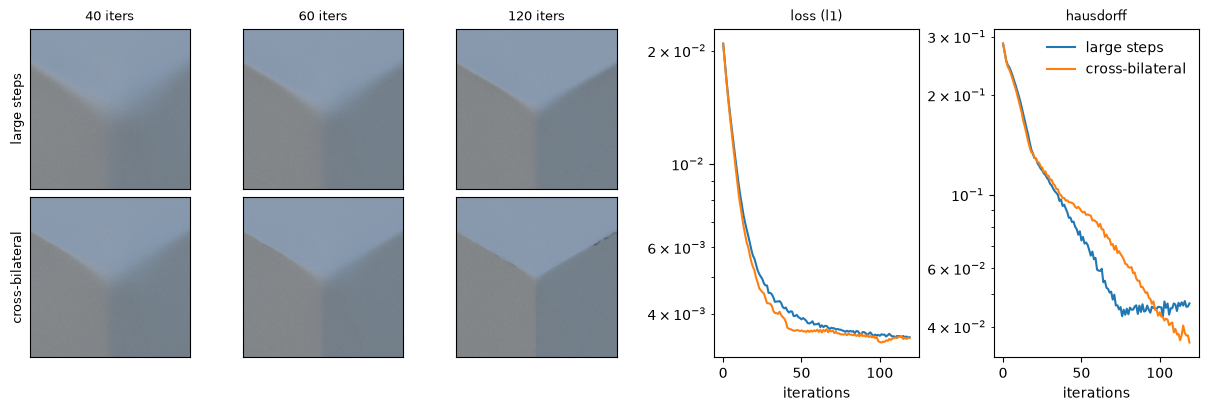

In [ ]:
zoom = mi.load_dict({
    'type': 'perspective', 'fov': 12,
    'to_world': T.look_at(target=[0.55, 0.55, 0.55], origin=[3, 3, 3], up=[0, 1, 0]),
    'film': {'type': 'hdrfilm', 'width': 400, 'height': 400,
             'filter': {'type': 'gaussian'}, 'sample_border': True},
    'sampler': {'type': 'independent', 'sample_count': 128}})


def render_zoom(v):
    params['shape.vertex_positions'] = mi.Float(v[dup_idx].astype(np.float32).ravel())
    params.update()
    return np.array(mi.render(scene, sensor=zoom, spp=128, seed=0))


fig = plt.figure(figsize=(12, 4), layout='constrained')
gs = fig.add_gridspec(2, 5)

for row, name in enumerate(['large steps', 'cross-bilateral']):
    for col, it in enumerate(snapshot_iters):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(np.clip(render_zoom(results[name]['snapshots'][it]) ** (1 / 2.2), 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'{it} iters', fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)

for offset, (key, label) in enumerate([('losses', 'loss (l1)'), ('hausdorff', 'hausdorff')]):
    ax = fig.add_subplot(gs[:, 3 + offset])
    ax.plot(results['large steps'][key], label='large steps')
    ax.plot(results['cross-bilateral'][key], label='cross-bilateral')
    ax.set_yscale('log'); ax.set_xlabel('iterations'); ax.set_title(label, fontsize=9)
ax.legend(frameon=False)